# Biological Competition Modeling (AI + Differential Equation)

Lotka-Volterra 기반 파라미터 추정 프로젝트

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

In [2]:
# 시간 길게 + 촘촘하게
t = np.linspace(0, 20, 3000)

# 기본 성장
X = 0.1 * np.exp(0.5*t) / (1 + 0.1*(np.exp(0.5*t)-1))
Y = 0.08 * np.exp(0.45*t) / (1 + 0.08*(np.exp(0.45*t)-1))

# 경쟁 + 비선형 추가 (이게 핵심)
Y = Y * (1 - 0.4*X + 0.05*X**2)
X = X * (1 - 0.3*Y + 0.03*Y**2)

# 노이즈 (현실성)
X += np.random.normal(0, 0.01, size=len(X))
Y += np.random.normal(0, 0.01, size=len(Y))

df = pd.DataFrame({
    "time": t,
    "X": X,
    "Y": Y
})

df.to_csv("competition_dataset_large.csv", index=False)

# df = pd.read_csv("competition_dataset.csv")

t = df["time"].values
X_data = df["X"].values
Y_data = df["Y"].values

In [3]:
# 미분 근사
dt = t[1] - t[0]
dX_dt = np.gradient(X_data, dt)
dY_dt = np.gradient(Y_data, dt)

In [4]:
# 모델
def model(params, X, Y):
    rX, rY, alpha, beta, KX, KY = params
    dX = rX * X * (1 - (X + alpha * Y) / KX)
    dY = rY * Y * (1 - (Y + beta * X) / KY)
    return dX, dY

In [5]:
# 손실 함수
def loss(params):
    pred_dX, pred_dY = model(params, X_data, Y_data)
    return np.mean((pred_dX - dX_dt)**2 + (pred_dY - dY_dt)**2)

In [6]:
# 최적화
init_params = [0.5, 0.5, 0.5, 0.5, 1.0, 1.0]
result = minimize(loss, init_params, method='L-BFGS-B')
params_opt = result.x
print("Optimized params:", params_opt)

Optimized params: [0.47659111 0.43943426 1.01867968 0.11749329 1.46415158 0.74899915]


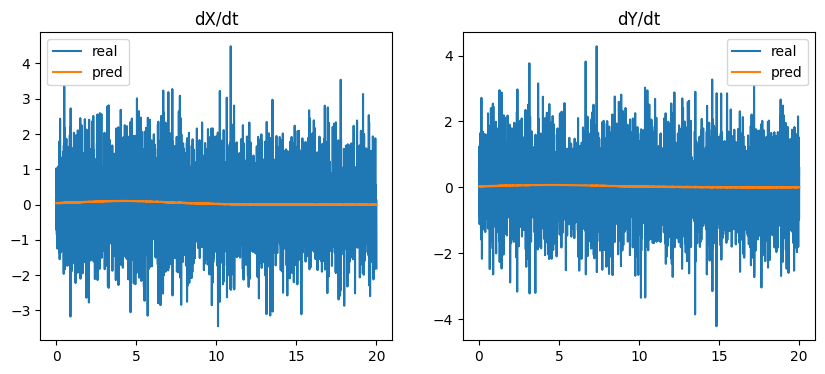

In [7]:
# 시각화
pred_dX, pred_dY = model(params_opt, X_data, Y_data)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("dX/dt")
plt.plot(t, dX_dt, label="real")
plt.plot(t, pred_dX, label="pred")
plt.legend()

plt.subplot(1,2,2)
plt.title("dY/dt")
plt.plot(t, dY_dt, label="real")
plt.plot(t, pred_dY, label="pred")
plt.legend()

plt.show()